In [2]:
import pandas as pd
import requests
from io import StringIO

url = "https://pub-cee805df54de4b6c8f93bee984e3c725.r2.dev/datasets/what-are-the-world-s-deadliest-animals/worlds_deadliest_animals.csv"

headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(url, headers=headers)

print(response.status_code)

df = pd.read_csv(StringIO(response.text))

df.head()

200


,Animal,Animal_Type,Number of humans killed per year,Estimate_Qualifier
0,Mosquitoes,Insect,760000,NaN
1,Humans,Mammal,600000,NaN
2,Snakes,Reptile,100000,NaN
3,Dogs,Mammal,40000,NaN
4,Freshwater snails,Mollusc,14000,NaN


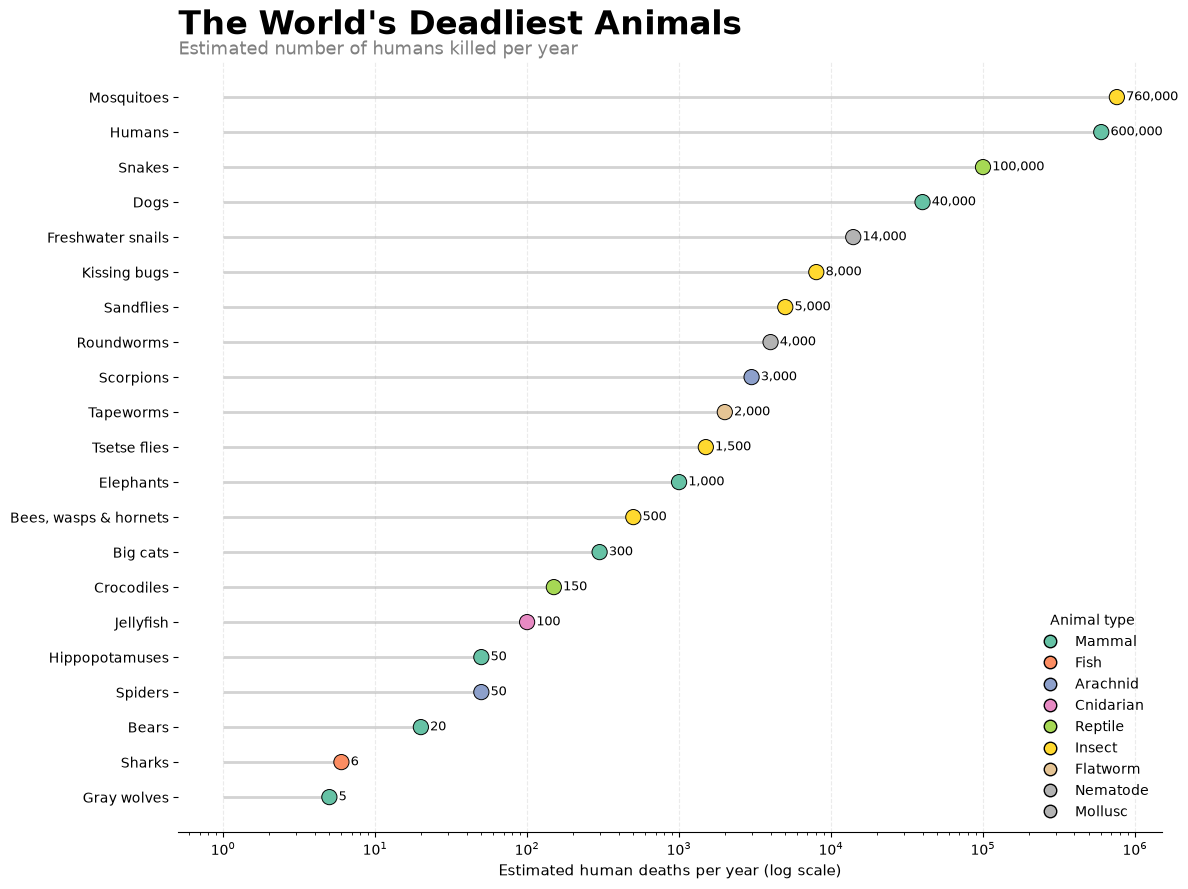

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# -----------------------------
# Prepare data
# -----------------------------
plot_df = df.sort_values(
    "Number of humans killed per year",
    ascending=True
).copy()

# -----------------------------
# Colors by animal type
# -----------------------------
types = plot_df["Animal_Type"].unique()
colors = plt.cm.Set2(np.linspace(0, 1, len(types)))

color_map = dict(zip(types, colors))
plot_df["Color"] = plot_df["Animal_Type"].map(color_map)

# -----------------------------
# Create figure
# -----------------------------
fig, ax = plt.subplots(figsize=(12, 9))

y = np.arange(len(plot_df))
x = plot_df["Number of humans killed per year"]

# -----------------------------
# Lollipop stems
# -----------------------------
ax.hlines(
    y=y,
    xmin=1,
    xmax=x,
    linewidth=2,
    color="lightgray",
    zorder=1
)

# -----------------------------
# Lollipop points
# -----------------------------
ax.scatter(
    x,
    y,
    s=120,
    c=plot_df["Color"],
    edgecolor="black",
    linewidth=0.7,
    zorder=2
)

# -----------------------------
# Value labels
# -----------------------------
for i, (_, row) in enumerate(plot_df.iterrows()):
    ax.text(
        row["Number of humans killed per year"] * 1.15,
        i,
        f'{row["Number of humans killed per year"]:,}',
        va="center",
        fontsize=9
    )

# -----------------------------
# Logarithmic x-axis
# -----------------------------
ax.set_xscale("log")

# -----------------------------
# Y-axis
# -----------------------------
ax.set_yticks(y)
ax.set_yticklabels(plot_df["Animal"], fontsize=10)

# -----------------------------
# Titles
# -----------------------------
ax.set_title(
    "The World's Deadliest Animals",
    fontsize=24,
    fontweight="bold",
    loc="left",
    pad=20
)

ax.text(
    0,
    1.01,
    "Estimated number of humans killed per year",
    transform=ax.transAxes,
    fontsize=13,
    color="gray"
)

ax.set_xlabel(
    "Estimated human deaths per year (log scale)",
    fontsize=11
)

# -----------------------------
# Grid
# -----------------------------
ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

# -----------------------------
# Remove unnecessary spines
# -----------------------------
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

# -----------------------------
# Legend
# -----------------------------
legend_elements = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        label=animal_type,
        markerfacecolor=color_map[animal_type],
        markeredgecolor="black",
        markersize=9
    )
    for animal_type in types
]

ax.legend(
    handles=legend_elements,
    title="Animal type",
    loc="lower right",
    frameon=False
)

# -----------------------------
# Layout
# -----------------------------
plt.tight_layout()
plt.show()